In [36]:

# Install the libraries needed for news collection and analysis
!pip -q install feedparser pandas matplotlib

In [37]:
#Collect news from Google News RSS
import feedparser
import pandas as pd
from datetime import datetime, timezone
from urllib.parse import quote

# Define the topics related to our project
topics = {
    "cybercrime": '"cybercrime" OR "online fraud" OR "digital scam"',
    "digital_exclusion": '"digital exclusion" OR "digital divide" OR "internet access"'
}

# Create an empty list to store the collected news articles
rows = []

# Collect news articles for each topic
for category, query in topics.items():

    # Create the Google News RSS search URL
    url = (
        "https://news.google.com/rss/search?q="
        + quote(query)
        + "&hl=en-IN&gl=IN&ceid=IN:en"
    )

    # Read the RSS feed
    feed = feedparser.parse(url)

    # Store the available details of each article
    for entry in feed.entries:
        rows.append({
            "title": entry.get("title", ""),
            "summary": entry.get("summary", ""),
            "url": entry.get("link", ""),
            "published_at": entry.get("published", ""),
            "collected_at": datetime.now(timezone.utc).isoformat(),
            "source": entry.get("source", {}).get("title", ""),
            "search_category": category
        })

# Convert the collected articles into a DataFrame
df = pd.DataFrame(rows)

# Display the number of articles collected
print("Total articles collected:", len(df))

# Display the first five rows
df.head()

Total articles collected: 200


,title,summary,url,published_at,collected_at,source,search_category
0,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiyAFBV...,"Mon, 21 Sep 2026 01:58:00 GMT",2026-09-21T07:48:20.435845+00:00,Reuters,cybercrime
1,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiwgFBV...,"Mon, 21 Sep 2026 01:57:09 GMT",2026-09-21T07:48:20.435890+00:00,Bhaskar English,cybercrime
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi5AFBV...,"Thu, 20 Aug 2026 07:00:00 GMT",2026-09-21T07:48:20.435908+00:00,The Hindu,cybercrime
3,Dial 1930: J&K Police’s new weapon against onl...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMioAFBV...,"Fri, 18 Sep 2026 21:46:37 GMT",2026-09-21T07:48:20.435923+00:00,Rising Kashmir,cybercrime
4,Survey finds 84% of Australians expect AI to i...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMisAFBV...,"Mon, 21 Sep 2026 04:53:48 GMT",2026-09-21T07:48:20.435938+00:00,Australian Cyber Security Magazine,cybercrime


In [38]:

# Save the collected news articles as a CSV file
filename = "DATA_VORTEX_R3_news_dataset_2.csv"

df.to_csv(filename, index=False, encoding="utf-8-sig")

# Display the file name and number of rows
print("CSV saved:", filename)
print("Rows:", len(df))

CSV saved: DATA_VORTEX_R3_news_dataset_2.csv
Rows: 200


In [39]:
from datetime import datetime, timezone
from pathlib import Path

# Define the output directory
OUT = Path("/content")
OUT.mkdir(exist_ok=True)

run_time = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
snapshot_path = OUT / f"news_snapshot_{run_time}.csv"

# Use 'df' instead of 'news_df'
df.to_csv(snapshot_path, index=False)

print("Snapshot saved:", snapshot_path)
print("Snapshot rows:", len(df))
print("Collection time (UTC):", run_time)

Snapshot saved: /content/news_snapshot_20260921_074821.csv
Snapshot rows: 200
Collection time (UTC): 20260921_074821


In [40]:

# Display the number of articles before cleaning
print("Before cleaning:", len(df))

# Remove duplicate articles using their URLs
df = df.drop_duplicates(subset=["url"])

# Remove rows that do not have a title
df = df.dropna(subset=["title"])

# Clean the title and summary text
df["title"] = df["title"].astype(str).str.strip()
df["summary"] = df["summary"].fillna("").astype(str)

# Remove articles with empty titles
df = df[df["title"] != ""]

# Display the number of articles after cleaning
print("After cleaning:", len(df))

# Display the cleaned dataset
df.head()

Before cleaning: 200
After cleaning: 200


,title,summary,url,published_at,collected_at,source,search_category
0,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiyAFBV...,"Mon, 21 Sep 2026 01:58:00 GMT",2026-09-21T07:48:20.435845+00:00,Reuters,cybercrime
1,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiwgFBV...,"Mon, 21 Sep 2026 01:57:09 GMT",2026-09-21T07:48:20.435890+00:00,Bhaskar English,cybercrime
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi5AFBV...,"Thu, 20 Aug 2026 07:00:00 GMT",2026-09-21T07:48:20.435908+00:00,The Hindu,cybercrime
3,Dial 1930: J&K Police’s new weapon against onl...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMioAFBV...,"Fri, 18 Sep 2026 21:46:37 GMT",2026-09-21T07:48:20.435923+00:00,Rising Kashmir,cybercrime
4,Survey finds 84% of Australians expect AI to i...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMisAFBV...,"Mon, 21 Sep 2026 04:53:48 GMT",2026-09-21T07:48:20.435938+00:00,Australian Cyber Security Magazine,cybercrime


In [41]:

# Create a timestamp for this data collection
snapshot_time = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

# Create a file name using the collection timestamp
snapshot_file = f"news_snapshot_{snapshot_time}.csv"

# Save the current dataset as a snapshot
df.to_csv(snapshot_file, index=False, encoding="utf-8-sig")

# Display the snapshot details
print("Snapshot saved:", snapshot_file)
print("Snapshot time (UTC):", snapshot_time)

Snapshot saved: news_snapshot_20260921_074821.csv
Snapshot time (UTC): 20260921_074821


In [42]:

# Display the total number of collected articles
print("Total rows:", len(df))

# Count articles in each search category
print("\nCategories:")
print(df["search_category"].value_counts())

# Check for missing values in each column
print("\nMissing values:")
print(df.isnull().sum())

# Display the publication date range available in the dataset
print("\nDate range:")
print("Earliest published:", df["published_at"].min())
print("Latest published:", df["published_at"].max())

Total rows: 200

Categories:
search_category
cybercrime           100
digital_exclusion    100
Name: count, dtype: int64

Missing values:
title              0
summary            0
url                0
published_at       0
collected_at       0
source             0
search_category    0
dtype: int64

Date range:
Earliest published: Fri, 04 Sep 2026 07:00:00 GMT
Latest published: Wed, 29 Jul 2026 11:04:57 GMT


In [43]:

# Save the cleaned dataset for further analysis
df.to_csv(
    "DATA_VORTEX_R3_news_dataset_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

# Confirm that the cleaned dataset is ready
print("Clean dataset ready!")

Clean dataset ready!


In [44]:
import zipfile
from pathlib import Path

# Use exact filename with spaces as uploaded in Colab
zip_path = Path("/content/DATA VORTEX ROUND 2.zip")

# Extract the ZIP file into a new folder
extract_folder = Path("/content/round2_files")
extract_folder.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

# Display the extracted files
for file in extract_folder.rglob("*"):
    if file.is_file():
        print(file.name)

topic_error_analysis_worksheet.csv
NLP_Round2.ipynb
sentiment_label_metrics (2).json
topic_category_metrics.json
topic_category_confusion_matrix.png
sentiment_label_confusion_matrix.png
topic_model.pkl
sentiment_model.pkl


In [45]:

# Import joblib to load the saved machine learning models
import joblib
from pathlib import Path

# Find the folder containing the Round 2 model files
model_folder = (
    Path("/content/round2_files")
    / "DATA VORTEX ROUND 2"
)

# Load the trained sentiment and topic models
sentiment_model = joblib.load(
    model_folder / "sentiment_model.pkl"
)

topic_model = joblib.load(
    model_folder / "topic_model.pkl"
)

# Confirm that both models are loaded
print("Sentiment model loaded:", type(sentiment_model))
print("Topic model loaded:", type(topic_model))

Sentiment model loaded: <class 'sklearn.pipeline.Pipeline'>
Topic model loaded: <class 'sklearn.pipeline.Pipeline'>


In [46]:

# Make a copy so the original collected data stays unchanged
df = df.copy()

# Check that the required columns are available
print("Available columns:", df.columns.tolist())

# Fill missing titles and summaries with empty text
df["title"] = df["title"].fillna("").astype(str)
df["summary"] = df["summary"].fillna("").astype(str)

# Combine the title and summary into one text column
df["analysis_text"] = (
    df["title"] + " " + df["summary"]
).str.strip()

# Remove rows that do not contain any text
df = df[df["analysis_text"] != ""].copy()

# Show a few examples
display(df[["title", "summary", "analysis_text"]].head())

Available columns: ['title', 'summary', 'url', 'published_at', 'collected_at', 'source', 'search_category']


,title,summary,analysis_text
0,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",Cybercrime feud erupts on dark web as notoriou...
1,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",Be careful before finding Garba partners onlin...
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",Mumbai Cybercrime police arrest two from Bihar...
3,Dial 1930: J&K Police’s new weapon against onl...,"<a href=""https://news.google.com/rss/articles/...",Dial 1930: J&K Police’s new weapon against onl...
4,Survey finds 84% of Australians expect AI to i...,"<a href=""https://news.google.com/rss/articles/...",Survey finds 84% of Australians expect AI to i...


In [47]:

# Run the saved Round 2 models on the collected news text
df["sentiment_prediction"] = sentiment_model.predict(
    df["analysis_text"]
)

df["topic_prediction"] = topic_model.predict(
    df["analysis_text"]
)

# Display the predictions for a few articles
display(
    df[
        [
            "title",
            "sentiment_prediction",
            "topic_prediction"
        ]
    ].head(10)
)

,title,sentiment_prediction,topic_prediction
0,Cybercrime feud erupts on dark web as notoriou...,Neutral,Community_Discussion
1,Be careful before finding Garba partners onlin...,Neutral,Community_Discussion
2,Mumbai Cybercrime police arrest two from Bihar...,Neutral,Community_Discussion
3,Dial 1930: J&K Police’s new weapon against onl...,Neutral,Community_Discussion
4,Survey finds 84% of Australians expect AI to i...,Neutral,Community_Discussion
5,Delhi Police cut cybercrime money restoration ...,Neutral,Community_Discussion
6,"‘Digital Arrests’ Fall 67%, Investment Fraud E...",Neutral,Community_Discussion
7,JKP Roll Out Dedicated Cybercrime Mechanism - ...,Neutral,Community_Discussion
8,Cybercrime feud erupts on dark web as notoriou...,Neutral,Community_Discussion
9,Report: 44 per cent of Australian cybercrime v...,Neutral,Community_Discussion


In [48]:

# Count how many articles received each sentiment label
print("Sentiment prediction counts:")
print(df["sentiment_prediction"].value_counts(dropna=False))

# Count how many articles received each topic label
print("\nTopic prediction counts:")
print(df["topic_prediction"].value_counts(dropna=False))

# Check the total number of analyzed articles
print("\nTotal analyzed articles:", len(df))

Sentiment prediction counts:
sentiment_prediction
Neutral     179
Negative     18
Positive      3
Name: count, dtype: int64

Topic prediction counts:
topic_prediction
Community_Discussion    196
Technical_Issues          2
Account_Security          1
Feature_Feedback          1
Name: count, dtype: int64

Total analyzed articles: 200


In [49]:

# Save the analyzed data as a CSV file
output_file = "/content/round3_analyzed_news.csv"

df.to_csv(output_file, index=False)

# Confirm where the file was saved
print("Analyzed dataset saved to:", output_file)

Analyzed dataset saved to: /content/round3_analyzed_news.csv


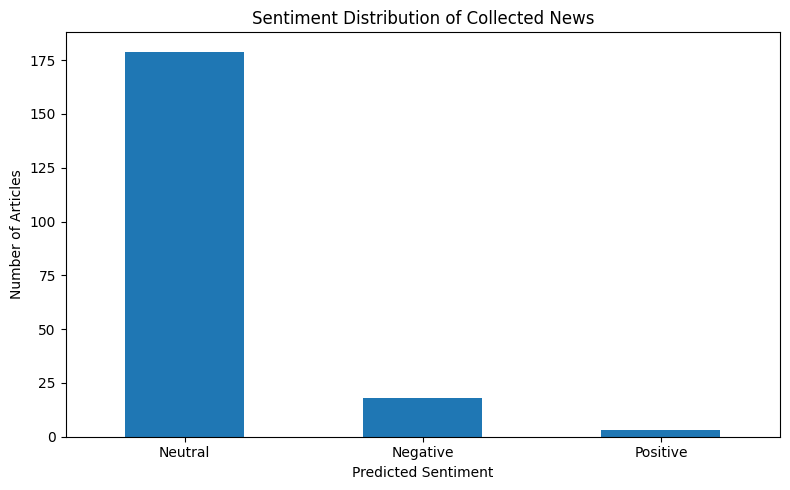

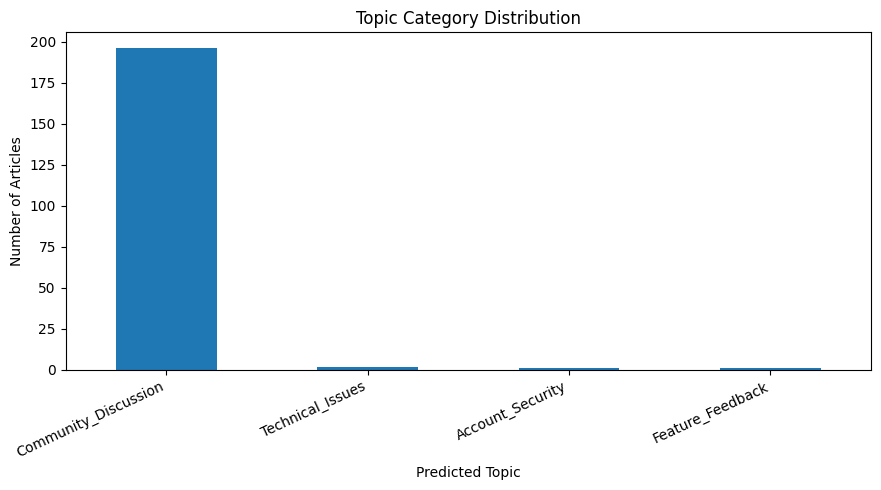

In [50]:

# Import libraries for making charts
import matplotlib.pyplot as plt

# Count sentiment predictions
sentiment_counts = df["sentiment_prediction"].value_counts()

# Create the sentiment chart
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution of Collected News")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Count topic predictions
topic_counts = df["topic_prediction"].value_counts()

# Create the topic chart
plt.figure(figsize=(9, 5))
topic_counts.plot(kind="bar")

plt.title("Topic Category Distribution")
plt.xlabel("Predicted Topic")
plt.ylabel("Number of Articles")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [51]:

# Display all available columns
print("Dataset columns:")
print(df.columns.tolist())

# Check whether timestamp columns are available
time_columns = [
    column for column in df.columns
    if "date" in column.lower()
    or "time" in column.lower()
    or "published" in column.lower()
    or "collected" in column.lower()
]

print("\nPossible time columns:")
print(time_columns)

# Show a few timestamp values
for column in time_columns:
    print(f"\n{column}:")
    print(df[column].head())

Dataset columns:
['title', 'summary', 'url', 'published_at', 'collected_at', 'source', 'search_category', 'analysis_text', 'sentiment_prediction', 'topic_prediction']

Possible time columns:
['published_at', 'collected_at', 'sentiment_prediction']

published_at:
0    Mon, 21 Sep 2026 01:58:00 GMT
1    Mon, 21 Sep 2026 01:57:09 GMT
2    Thu, 20 Aug 2026 07:00:00 GMT
3    Fri, 18 Sep 2026 21:46:37 GMT
4    Mon, 21 Sep 2026 04:53:48 GMT
Name: published_at, dtype: object

collected_at:
0    2026-09-21T07:48:20.435845+00:00
1    2026-09-21T07:48:20.435890+00:00
2    2026-09-21T07:48:20.435908+00:00
3    2026-09-21T07:48:20.435923+00:00
4    2026-09-21T07:48:20.435938+00:00
Name: collected_at, dtype: object

sentiment_prediction:
0    Neutral
1    Neutral
2    Neutral
3    Neutral
4    Neutral
Name: sentiment_prediction, dtype: object


In [52]:

# Calculate the number and percentage of each predicted sentiment
sentiment_summary = (
    df["sentiment_prediction"]
    .value_counts()
    .rename_axis("Predicted Sentiment")
    .reset_index(name="Article Count")
)

sentiment_summary["Percentage"] = (
    sentiment_summary["Article Count"] / len(df) * 100
).round(1)

# Display the summary for the report
display(sentiment_summary)

,Predicted Sentiment,Article Count,Percentage
0,Neutral,179,89.5
1,Negative,18,9.0
2,Positive,3,1.5


In [53]:

# Check the topic labels used by the saved Round 2 model
print("Topic model classes:")

if hasattr(topic_model, "classes_"):
    print(topic_model.classes_)

elif hasattr(topic_model, "named_steps"):
    # Find the classifier inside the saved pipeline
    for step_name, step_model in topic_model.named_steps.items():
        if hasattr(step_model, "classes_"):
            print(step_name, ":", step_model.classes_)

else:
    print("Could not find class labels automatically.")

Topic model classes:
['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']


In [54]:

# Select the first 20 articles for manual review
review_columns = [
    "title",
    "summary",
    "sentiment_prediction",
    "topic_prediction"
]

review_sample = df[review_columns].head(20).copy()

# Add columns for human review
review_sample["Manual Sentiment"] = ""
review_sample["Manual Cybercrime Topic"] = ""
review_sample["Notes"] = ""

# Display the sample
display(review_sample)

# Save the sample as a CSV file
review_sample.to_csv(
    "/content/manual_review_sample.csv",
    index=False
)

print("Manual review sample saved.")

,title,summary,sentiment_prediction,topic_prediction,Manual Sentiment,Manual Cybercrime Topic,Notes
0,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
1,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
3,Dial 1930: J&K Police’s new weapon against onl...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
4,Survey finds 84% of Australians expect AI to i...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
5,Delhi Police cut cybercrime money restoration ...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
6,"‘Digital Arrests’ Fall 67%, Investment Fraud E...","<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
7,JKP Roll Out Dedicated Cybercrime Mechanism - ...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
8,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,
9,Report: 44 per cent of Australian cybercrime v...,"<a href=""https://news.google.com/rss/articles/...",Neutral,Community_Discussion,,,


Manual review sample saved.


In [55]:

import re

# Define keywords for exploratory topic tagging
topic_keywords = {
    "Online_Fraud": [
        "online fraud", "cyber fraud",
        "online scam", "digital scam"
    ],
    "Phishing": [
        "phishing", "fake link", "spoofing"
    ],
    "Cybercrime": [
        "cybercrime", "cyber crime",
        "hacking", "data breach", "ransomware"
    ],
    "Digital_Exclusion": [
        "digital divide", "digital exclusion",
        "internet access", "digital literacy"
    ]
}

# Match keywords in the article text
def find_topic_tags(text):
    text = str(text).lower()
    matched_topics = []

    for topic, keywords in topic_keywords.items():
        for keyword in keywords:
            if re.search(
                r"\b" + re.escape(keyword) + r"\b",
                text
            ):
                matched_topics.append(topic)
                break

    if not matched_topics:
        matched_topics.append("No_Keyword_Match")

    return ", ".join(matched_topics)

# Apply the keyword rules to the dataset
df["exploratory_topic_tags"] = df["analysis_text"].apply(
    find_topic_tags
)

# Count all matching tags
tag_counts = (
    df["exploratory_topic_tags"]
    .str.split(", ")
    .explode()
    .value_counts()
)

print("Exploratory keyword tag counts:")
print(tag_counts)

Exploratory keyword tag counts:
exploratory_topic_tags
Digital_Exclusion    94
Cybercrime           84
No_Keyword_Match     17
Online_Fraud          6
Name: count, dtype: int64


In [56]:

import re

# Define keywords for exploratory topic tagging
topic_keywords = {
    "Online_Fraud": [
        "online fraud", "cyber fraud",
        "online scam", "digital scam"
    ],
    "Phishing": [
        "phishing", "fake link", "spoofing"
    ],
    "Account_Security": [
        "account security", "account hacked",
        "password theft", "identity theft"
    ],
    "Cybercrime": [
        "cybercrime", "cyber crime",
        "hacking", "data breach", "ransomware"
    ],
    "Digital_Exclusion": [
        "digital divide", "digital exclusion",
        "internet access", "digital literacy"
    ]
}

# Find topic keywords in each article
def find_topic_tags(text):
    text = str(text).lower()
    matched_topics = []

    for topic, keywords in topic_keywords.items():
        for keyword in keywords:
            if re.search(
                r"\b" + re.escape(keyword) + r"\b",
                text
            ):
                matched_topics.append(topic)
                break

    # Mark articles that have no matching keywords
    if not matched_topics:
        matched_topics.append("No_Keyword_Match")

    return ", ".join(matched_topics)

# Apply keyword tagging to the article text
df["exploratory_topic_tags"] = df["analysis_text"].apply(
    find_topic_tags
)

# Count all topic tags
tag_counts = (
    df["exploratory_topic_tags"]
    .str.split(", ")
    .explode()
    .value_counts()
)

print("Exploratory topic tag counts:")
print(tag_counts)

Exploratory topic tag counts:
exploratory_topic_tags
Digital_Exclusion    94
Cybercrime           84
No_Keyword_Match     17
Online_Fraud          6
Name: count, dtype: int64


In [57]:

# Check which columns are available in the dataset
print("All dataset columns:")
print(df.columns.tolist())

# Find columns that may contain dates or timestamps
time_columns = [
    column for column in df.columns
    if any(word in column.lower() for word in [
        "date", "time", "published", "collected"
    ])
]

print("\nPossible timestamp columns:")
print(time_columns)

# Display sample values from each timestamp column
for column in time_columns:
    print(f"\nSample values from {column}:")
    print(df[column].head())

All dataset columns:
['title', 'summary', 'url', 'published_at', 'collected_at', 'source', 'search_category', 'analysis_text', 'sentiment_prediction', 'topic_prediction', 'exploratory_topic_tags']

Possible timestamp columns:
['published_at', 'collected_at', 'sentiment_prediction']

Sample values from published_at:
0    Mon, 21 Sep 2026 01:58:00 GMT
1    Mon, 21 Sep 2026 01:57:09 GMT
2    Thu, 20 Aug 2026 07:00:00 GMT
3    Fri, 18 Sep 2026 21:46:37 GMT
4    Mon, 21 Sep 2026 04:53:48 GMT
Name: published_at, dtype: object

Sample values from collected_at:
0    2026-09-21T07:48:20.435845+00:00
1    2026-09-21T07:48:20.435890+00:00
2    2026-09-21T07:48:20.435908+00:00
3    2026-09-21T07:48:20.435923+00:00
4    2026-09-21T07:48:20.435938+00:00
Name: collected_at, dtype: object

Sample values from sentiment_prediction:
0    Neutral
1    Neutral
2    Neutral
3    Neutral
4    Neutral
Name: sentiment_prediction, dtype: object


In [58]:

# Save the dataset with model predictions and keyword tags
output_file = "/content/round3_analyzed_news.csv"

df.to_csv(output_file, index=False)

print("Updated dataset saved to:", output_file)

Updated dataset saved to: /content/round3_analyzed_news.csv


In [59]:

import pandas as pd

# Convert publication and collection timestamps into datetime format
df["published_at"] = pd.to_datetime(
    df["published_at"],
    errors="coerce",
    utc=True
)

df["collected_at"] = pd.to_datetime(
    df["collected_at"],
    errors="coerce",
    utc=True
)

# Check how many timestamps were successfully parsed
print("Valid publication dates:", df["published_at"].notna().sum())
print("Valid collection dates:", df["collected_at"].notna().sum())

# Display the earliest and latest publication dates
print("\nEarliest publication date:", df["published_at"].min())
print("Latest publication date:", df["published_at"].max())

# Check how many different collection times are present
print(
    "\nUnique collection timestamps:",
    df["collected_at"].nunique()
)

Valid publication dates: 200
Valid collection dates: 200

Earliest publication date: 1970-01-01 00:00:00+00:00
Latest publication date: 2026-09-21 07:45:38+00:00

Unique collection timestamps: 200


In [60]:
# Convert publication date to datetime and group by date & sentiment
df["date"] = pd.to_datetime(df["published_at"]).dt.date
daily_sentiment = df.groupby(["date", "sentiment_prediction"]).size().unstack(fill_value=0)

# Calculate percentage if needed
daily_percent = daily_sentiment.div(daily_sentiment.sum(axis=1), axis=0) * 100

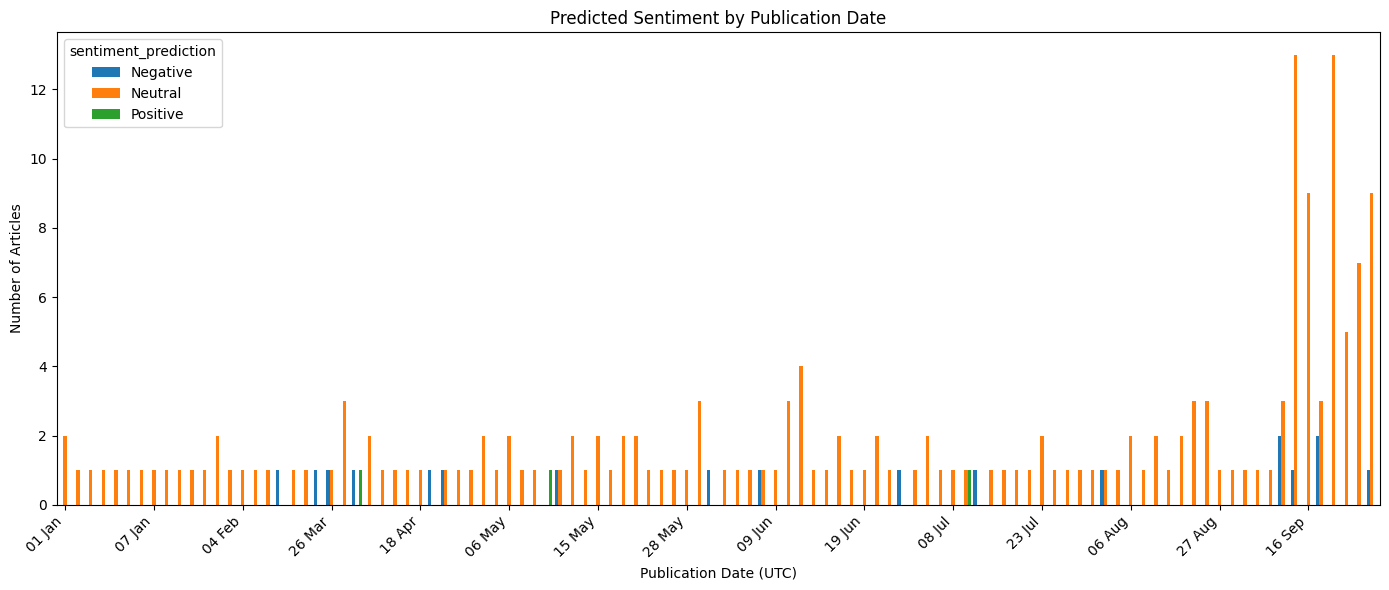

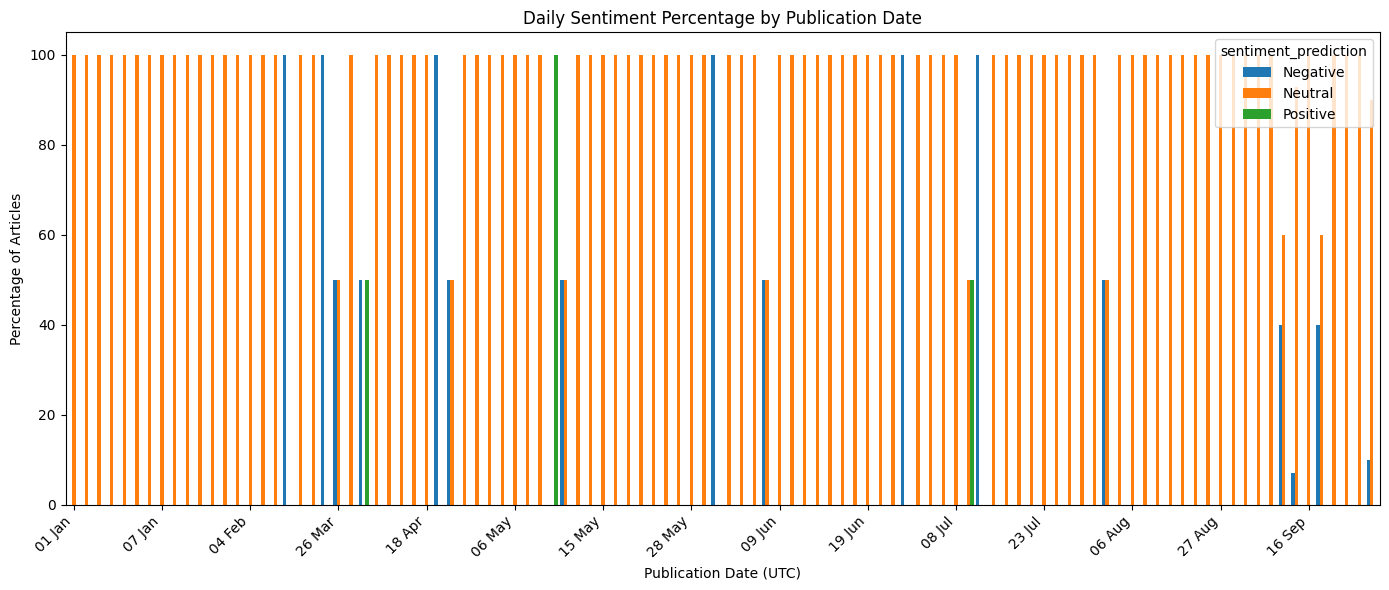

In [61]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert the date index into datetime format
daily_sentiment.index = pd.to_datetime(
    daily_sentiment.index
)

# Sort dates in chronological order
daily_sentiment = daily_sentiment.sort_index()

# Create the first chart with readable date labels
fig, ax = plt.subplots(figsize=(14, 6))

daily_sentiment.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

# Show fewer date labels to avoid overlapping
tick_positions = range(0, len(daily_sentiment), 7)
ax.set_xticks(list(tick_positions))

# Format the displayed dates
ax.set_xticklabels(
    daily_sentiment.index[::7].strftime("%d %b"),
    rotation=45,
    ha="right"
)

ax.set_title("Predicted Sentiment by Publication Date")
ax.set_xlabel("Publication Date (UTC)")
ax.set_ylabel("Number of Articles")

plt.tight_layout()
plt.show()


# Calculate daily sentiment percentages
daily_percent = daily_sentiment.div(
    daily_sentiment.sum(axis=1),
    axis=0
) * 100

# Create the percentage chart
fig, ax = plt.subplots(figsize=(14, 6))

daily_percent.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

# Show one date label every seven days
ax.set_xticks(list(tick_positions))

ax.set_xticklabels(
    daily_percent.index[::7].strftime("%d %b"),
    rotation=45,
    ha="right"
)

ax.set_title("Daily Sentiment Percentage by Publication Date")
ax.set_xlabel("Publication Date (UTC)")
ax.set_ylabel("Percentage of Articles")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1925/3746707457.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W")


sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0
2025-12-22/2025-12-28,0,1,0
2026-01-05/2026-01-11,0,1,0
2026-01-12/2026-01-18,0,1,0
2026-01-19/2026-01-25,0,2,0


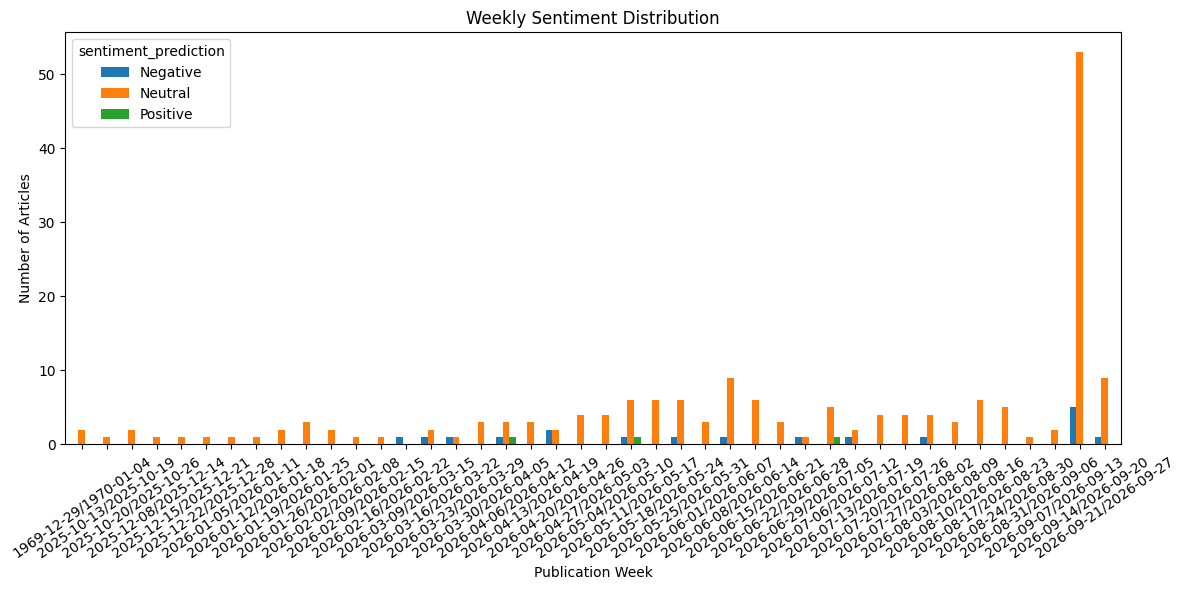

In [62]:

# Make sure the publication date column is in datetime format
df["published_at"] = pd.to_datetime(
    df["published_at"],
    errors="coerce",
    utc=True
)

# Keep rows with valid publication dates
weekly_df = df.dropna(subset=["published_at"]).copy()

# Group publication dates by week
weekly_df["week"] = (
    weekly_df["published_at"]
    .dt.to_period("W")
    .astype(str)
)

# Count predicted sentiments for each week
weekly_sentiment = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Show the weekly counts
display(weekly_sentiment)

# Plot weekly sentiment counts
ax = weekly_sentiment.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title("Weekly Sentiment Distribution")
ax.set_xlabel("Publication Week")
ax.set_ylabel("Number of Articles")
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0.0,100.0,0.0
2025-10-13/2025-10-19,0.0,100.0,0.0
2025-10-20/2025-10-26,0.0,100.0,0.0
2025-12-08/2025-12-14,0.0,100.0,0.0
2025-12-15/2025-12-21,0.0,100.0,0.0
2025-12-22/2025-12-28,0.0,100.0,0.0
2026-01-05/2026-01-11,0.0,100.0,0.0
2026-01-12/2026-01-18,0.0,100.0,0.0
2026-01-19/2026-01-25,0.0,100.0,0.0


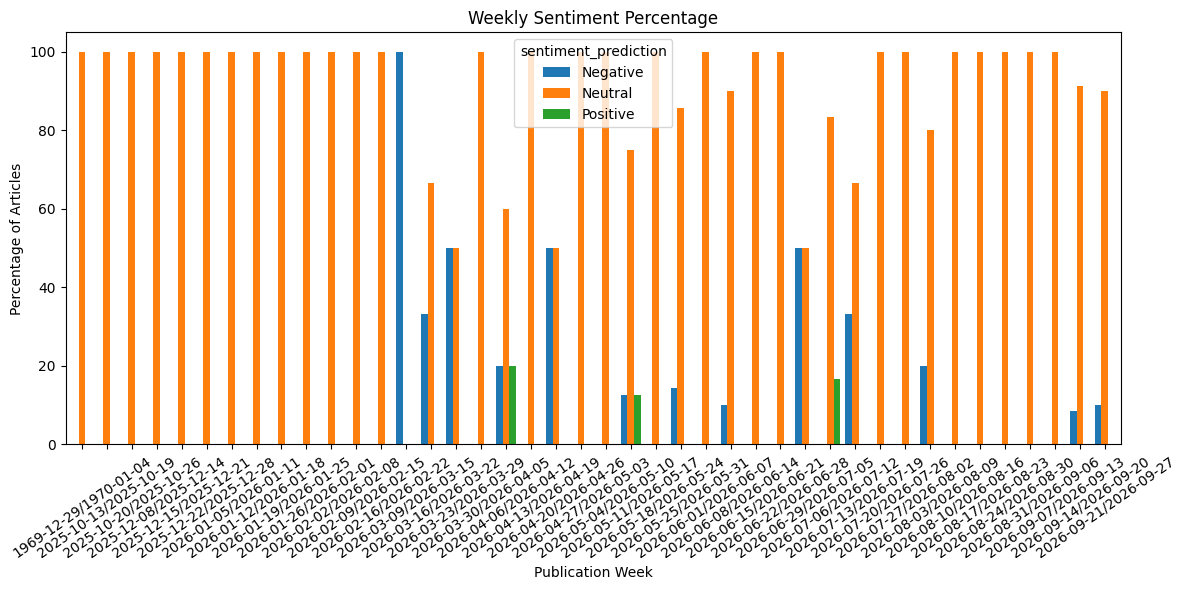

In [63]:

# Convert weekly counts into percentages
weekly_percent = weekly_sentiment.div(
    weekly_sentiment.sum(axis=1),
    axis=0
) * 100

# Display the weekly percentages
display(weekly_percent.round(1))

# Plot weekly sentiment percentages
ax = weekly_percent.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_title("Weekly Sentiment Percentage")
ax.set_xlabel("Publication Week")
ax.set_ylabel("Percentage of Articles")
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [64]:

# Convert publication dates safely
df["published_at"] = pd.to_datetime(
    df["published_at"],
    errors="coerce",
    utc=True
)

# Find dates before 1970
old_dates = df[
    df["published_at"] < "1970-01-01"
]

# Display suspicious records for inspection
display(
    old_dates[
        ["title", "published_at", "url"]
    ]
)

print("Suspicious records:", len(old_dates))

,title,published_at,url


Suspicious records: 0


In [65]:

# Keep only valid publication dates
weekly_df = df.dropna(
    subset=["published_at"]
).copy()

# Remove dates before 1970 only after checking Step 32
weekly_df = weekly_df[
    weekly_df["published_at"] >= "1970-01-01"
].copy()

# Convert timestamps directly into weekly periods
weekly_df["week"] = (
    weekly_df["published_at"]
    .dt.tz_convert(None)
    .dt.to_period("W")
)

# Count predicted sentiments for each week
weekly_clean = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Display the corrected weekly table
display(weekly_clean)

sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0
2025-12-22/2025-12-28,0,1,0
2026-01-05/2026-01-11,0,1,0
2026-01-12/2026-01-18,0,1,0
2026-01-19/2026-01-25,0,2,0


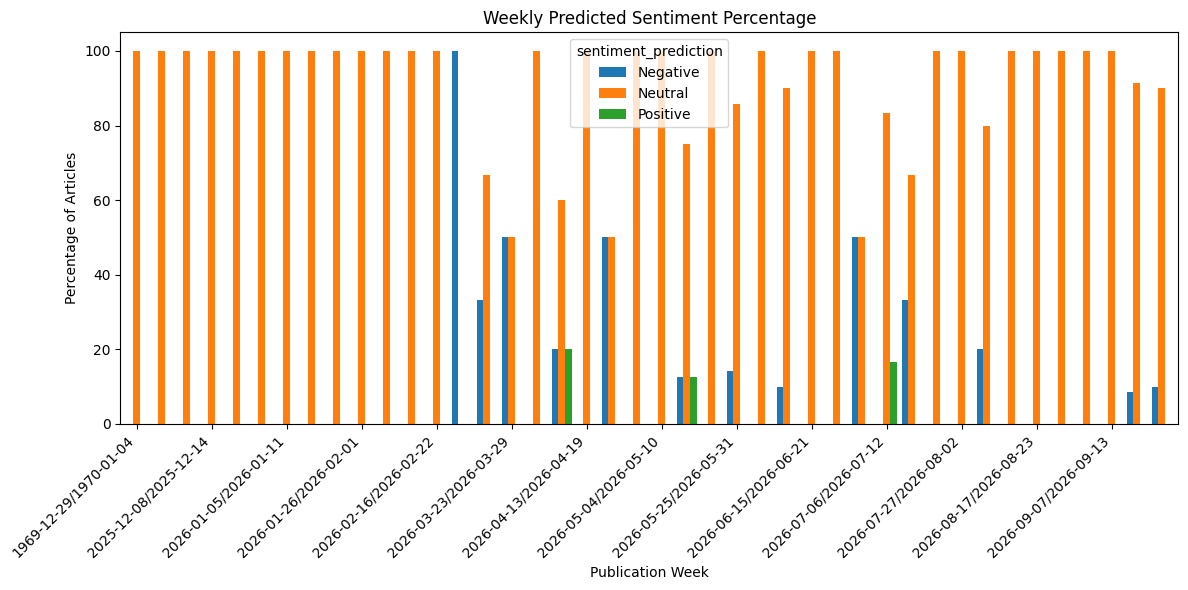

In [66]:

# Calculate weekly sentiment percentages
weekly_percent = weekly_clean.div(
    weekly_clean.sum(axis=1),
    axis=0
) * 100

# Create the chart
fig, ax = plt.subplots(figsize=(12, 6))

weekly_percent.plot(
    kind="bar",
    ax=ax,
    width=0.8
)

# Display fewer date labels
step = max(1, len(weekly_percent) // 12)
positions = list(range(0, len(weekly_percent), step))

ax.set_xticks(positions)
ax.set_xticklabels(
    [str(weekly_percent.index[i]) for i in positions],
    rotation=45,
    ha="right"
)

ax.set_title("Weekly Predicted Sentiment Percentage")
ax.set_xlabel("Publication Week")
ax.set_ylabel("Percentage of Articles")

plt.tight_layout()
plt.show()

In [67]:

# Make a fresh copy of the dataset
weekly_df = df.copy()

# Keep only rows with valid publication dates
weekly_df = weekly_df.dropna(
    subset=["published_at"]
).copy()

# Remove timezone information before weekly grouping
weekly_df["published_at"] = (
    weekly_df["published_at"].dt.tz_convert(None)
)

# Create weekly periods directly from timestamps
weekly_df["week"] = (
    weekly_df["published_at"].dt.to_period("W")
)

# Count predicted sentiments for each week
weekly_clean = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Display the first and last weeks
print("First weeks:")
display(weekly_clean.head())

print("Latest weeks:")
display(weekly_clean.tail())

# Check the earliest and latest week
print("Earliest week:", weekly_clean.index.min())
print("Latest week:", weekly_clean.index.max())

First weeks:


sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0


Latest weeks:


sentiment_prediction,Negative,Neutral,Positive
week,,,
2026-08-24/2026-08-30,0,5,0
2026-08-31/2026-09-06,0,1,0
2026-09-07/2026-09-13,0,2,0
2026-09-14/2026-09-20,5,53,0
2026-09-21/2026-09-27,1,9,0


Earliest week: 1969-12-29/1970-01-04
Latest week: 2026-09-21/2026-09-27


In [68]:

# Save weekly sentiment counts for the report
weekly_clean.to_csv(
    "/content/round3_weekly_sentiment.csv"
)

print("Weekly sentiment table saved.")

Weekly sentiment table saved.


In [69]:
# Check the current date column and its earliest values
print("Date column type:", df["published_at"].dtype)
print("Earliest published date:", df["published_at"].min())
print("Latest published date:", df["published_at"].max())

# Show records around the suspicious date
print("\nRecords before 1970:")
display(df.loc[df["published_at"] < pd.Timestamp("1970-01-01", tz="UTC"),
               ["title", "published_at"]])

# Check how many dates are missing
print("\nMissing published dates:", df["published_at"].isna().sum())

Date column type: datetime64[ns, UTC]
Earliest published date: 1970-01-01 00:00:00+00:00
Latest published date: 2026-09-21 07:45:38+00:00

Records before 1970:


,title,published_at



Missing published dates: 0


In [70]:
# Create a fresh copy for weekly analysis
weekly_df = df.copy()

# Keep records with valid publication dates
weekly_df = weekly_df.dropna(subset=["published_at"]).copy()

# Make sure the dates are in UTC
weekly_df["published_at"] = pd.to_datetime(
    weekly_df["published_at"], errors="coerce", utc=True
)

# Remove any dates that could not be parsed
weekly_df = weekly_df.dropna(subset=["published_at"]).copy()

# Group articles by publication week and predicted sentiment
weekly_df["week"] = (
    weekly_df["published_at"]
    .dt.tz_convert(None)
    .dt.to_period("W")
)

weekly_clean = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Display the first and last weeks
display(weekly_clean.head())
display(weekly_clean.tail())

print("Earliest week:", weekly_clean.index.min())
print("Latest week:", weekly_clean.index.max())

sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0


sentiment_prediction,Negative,Neutral,Positive
week,,,
2026-08-24/2026-08-30,0,5,0
2026-08-31/2026-09-06,0,1,0
2026-09-07/2026-09-13,0,2,0
2026-09-14/2026-09-20,5,53,0
2026-09-21/2026-09-27,1,9,0


Earliest week: 1969-12-29/1970-01-04
Latest week: 2026-09-21/2026-09-27


In [71]:
# Check the earliest and latest publication dates
print("Date type:", df["published_at"].dtype)
print("Earliest date:", df["published_at"].min())
print("Latest date:", df["published_at"].max())

# Show records from before 1970
old_dates = df[
    df["published_at"] < pd.Timestamp("1970-01-01", tz="UTC")
]

print("Records before 1970:", len(old_dates))
display(old_dates[["title", "published_at"]])

Date type: datetime64[ns, UTC]
Earliest date: 1970-01-01 00:00:00+00:00
Latest date: 2026-09-21 07:45:38+00:00
Records before 1970: 0


,title,published_at


In [72]:
# Create a fresh copy for weekly analysis
weekly_df = df.copy()

# Keep valid publication dates
weekly_df = weekly_df.dropna(subset=["published_at"]).copy()

# Convert dates to UTC datetime
weekly_df["published_at"] = pd.to_datetime(
    weekly_df["published_at"], errors="coerce", utc=True
)

# Remove dates that could not be parsed
weekly_df = weekly_df.dropna(subset=["published_at"]).copy()

# Create weekly periods
weekly_df["week"] = (
    weekly_df["published_at"]
    .dt.tz_convert(None)
    .dt.to_period("W")
)

# Count predicted sentiments for each week
weekly_clean = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Display the refreshed weekly table
display(weekly_clean)

print("Earliest week:", weekly_clean.index.min())
print("Latest week:", weekly_clean.index.max())

sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0
2025-12-22/2025-12-28,0,1,0
2026-01-05/2026-01-11,0,1,0
2026-01-12/2026-01-18,0,1,0
2026-01-19/2026-01-25,0,2,0


Earliest week: 1969-12-29/1970-01-04
Latest week: 2026-09-21/2026-09-27


In [73]:
# Create a fresh weekly analysis copy
weekly_df = df.copy()

# Convert publication dates to UTC
weekly_df["published_at"] = pd.to_datetime(
    weekly_df["published_at"], errors="coerce", utc=True
)

# Remove invalid dates
weekly_df = weekly_df.dropna(subset=["published_at"]).copy()

# Create weekly groups
weekly_df["week"] = (
    weekly_df["published_at"]
    .dt.tz_convert(None)
    .dt.to_period("W")
)

# Count sentiment predictions by week
weekly_clean = pd.crosstab(
    weekly_df["week"],
    weekly_df["sentiment_prediction"]
)

# Remove any week before 1970, if present
weekly_clean = weekly_clean[
    weekly_clean.index >= pd.Period("1970-01-01", freq="W")
]

# Show the cleaned table
display(weekly_clean.head())
display(weekly_clean.tail())

print("Earliest week:", weekly_clean.index.min())
print("Latest week:", weekly_clean.index.max())

sentiment_prediction,Negative,Neutral,Positive
week,,,
1969-12-29/1970-01-04,0,2,0
2025-10-13/2025-10-19,0,1,0
2025-10-20/2025-10-26,0,2,0
2025-12-08/2025-12-14,0,1,0
2025-12-15/2025-12-21,0,1,0


sentiment_prediction,Negative,Neutral,Positive
week,,,
2026-08-24/2026-08-30,0,5,0
2026-08-31/2026-09-06,0,1,0
2026-09-07/2026-09-13,0,2,0
2026-09-14/2026-09-20,5,53,0
2026-09-21/2026-09-27,1,9,0


Earliest week: 1969-12-29/1970-01-04
Latest week: 2026-09-21/2026-09-27


In [74]:
# Save the cleaned weekly sentiment table
weekly_clean.to_csv("/content/round3_weekly_sentiment.csv")

print("Clean weekly sentiment CSV saved.")

Clean weekly sentiment CSV saved.


In [75]:
# Make a copy for daily activity analysis
activity_df = df.copy()

# Convert publication dates to UTC
activity_df["published_at"] = pd.to_datetime(
    activity_df["published_at"], errors="coerce", utc=True
)

# Remove rows with invalid publication dates
activity_df = activity_df.dropna(subset=["published_at"]).copy()

# Extract the publication date
activity_df["publication_date"] = (
    activity_df["published_at"].dt.date
)

# Count articles published each day
daily_activity = (
    activity_df.groupby("publication_date")
    .size()
    .reset_index(name="article_count")
)

# Sort dates from oldest to newest
daily_activity = daily_activity.sort_values("publication_date")

# Display the daily article counts
display(daily_activity)

# Show the date with the highest article count
if not daily_activity.empty:
    busiest_day = daily_activity.loc[
        daily_activity["article_count"].idxmax()
    ]
    print("Busiest publication date:", busiest_day["publication_date"])
    print("Articles published:", busiest_day["article_count"])

,publication_date,article_count
0,1970-01-01,2
1,2025-10-17,1
2,2025-10-23,1
3,2025-10-25,1
4,2025-12-12,1
...,...,...
99,2026-09-17,5
100,2026-09-18,13
101,2026-09-19,5
102,2026-09-20,7


Busiest publication date: 2026-09-15
Articles published: 14


In [76]:
# Save daily article activity
daily_activity.to_csv(
    "/content/round3_daily_activity.csv",
    index=False
)

print("Daily activity CSV saved.")

Daily activity CSV saved.


In [77]:
# Convert collection timestamps to UTC
df["collected_at"] = pd.to_datetime(
    df["collected_at"], errors="coerce", utc=True
)

# Show collection time range
print("First collection time:", df["collected_at"].min())
print("Last collection time:", df["collected_at"].max())

# Count distinct collection timestamps
print(
    "Unique collection timestamps:",
    df["collected_at"].nunique()
)

First collection time: 2026-09-21 07:48:20.435845+00:00
Last collection time: 2026-09-21 07:48:21.109990+00:00
Unique collection timestamps: 200


In [78]:
# Group article collection times by minute
df["collected_at"] = pd.to_datetime(
    df["collected_at"], errors="coerce", utc=True
)

df["collection_minute"] = df["collected_at"].dt.floor("min")

collection_batches = (
    df.groupby("collection_minute")
    .size()
    .reset_index(name="article_count")
)

display(collection_batches)

print("Collection batches:", len(collection_batches))
print("Total articles:", len(df))

,collection_minute,article_count
0,2026-09-21 07:48:00+00:00,200


Collection batches: 1
Total articles: 200


In [79]:
# Count sentiment predictions
sentiment_summary = (
    df["sentiment_prediction"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="article_count")
)

# Count topic predictions
topic_summary = (
    df["topic_prediction"]
    .value_counts()
    .rename_axis("topic")
    .reset_index(name="article_count")
)

# Count exploratory keyword tags
keyword_summary = (
    df["exploratory_topic_tags"]
    .value_counts()
    .rename_axis("keyword_tag")
    .reset_index(name="article_count")
)

print("Sentiment summary:")
display(sentiment_summary)

print("Topic summary:")
display(topic_summary)

print("Keyword tag summary:")
display(keyword_summary)

Sentiment summary:


,sentiment,article_count
0,Neutral,179
1,Negative,18
2,Positive,3


Topic summary:


,topic,article_count
0,Community_Discussion,196
1,Technical_Issues,2
2,Account_Security,1
3,Feature_Feedback,1


Keyword tag summary:


,keyword_tag,article_count
0,Digital_Exclusion,94
1,Cybercrime,83
2,No_Keyword_Match,17
3,Online_Fraud,5
4,"Online_Fraud, Cybercrime",1


In [80]:
# Save sentiment summary
sentiment_summary.to_csv(
    "/content/round3_sentiment_summary.csv",
    index=False
)

# Save topic summary
topic_summary.to_csv(
    "/content/round3_topic_summary.csv",
    index=False
)

# Save keyword summary
keyword_summary.to_csv(
    "/content/round3_keyword_summary.csv",
    index=False
)

# Save collection batch summary
collection_batches.to_csv(
    "/content/round3_collection_batches.csv",
    index=False
)

print("All summary CSV files saved.")

All summary CSV files saved.


In [81]:
# Count collection timestamps by minute
print("Unique collection minutes:",
      df["collected_at"].dt.floor("min").nunique())

# Show the collection time range
print("First collection:",
      df["collected_at"].min())

print("Last collection:",
      df["collected_at"].max())

Unique collection minutes: 1
First collection: 2026-09-21 07:48:20.435845+00:00
Last collection: 2026-09-21 07:48:21.109990+00:00


In [82]:
# Inspect records with the earliest publication date
earliest_date = df["published_at"].min()

print("Earliest date:", earliest_date)

display(
    df.loc[
        df["published_at"] == earliest_date,
        ["title", "published_at", "source", "url"]
    ]
)

Earliest date: 1970-01-01 00:00:00+00:00


,title,published_at,source,url
24,Spotlight Cybercrime Impact - Interpol,1970-01-01 00:00:00+00:00,Interpol,https://news.google.com/rss/articles/CBMirwFBV...
43,House Passes Legislation to Strengthen Cybercr...,1970-01-01 00:00:00+00:00,Jamaica Information Service (JIS),https://news.google.com/rss/articles/CBMihgFBV...


In [83]:
# Inspect the original date values for the affected articles
bad_date_rows = df[
    df["published_at"] == pd.Timestamp("1970-01-01", tz="UTC")
]

display(
    bad_date_rows[
        ["title", "published_at", "url", "source"]
    ]
)

,title,published_at,url,source
24,Spotlight Cybercrime Impact - Interpol,1970-01-01 00:00:00+00:00,https://news.google.com/rss/articles/CBMirwFBV...,Interpol
43,House Passes Legislation to Strengthen Cybercr...,1970-01-01 00:00:00+00:00,https://news.google.com/rss/articles/CBMihgFBV...,Jamaica Information Service (JIS)


In [84]:
# Count articles collected from each news source
source_summary = (
    df["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="article_count")
)

# Display the source-wise summary
display(source_summary)

# Show how many unique sources are present
print("Number of news sources:", df["source"].nunique())

,source,article_count
0,coe.int,11
1,Nature,6
2,Interpol,5
3,United Nations Office on Drugs and Crime,4
4,Frontiers,4
...,...,...
146,The Michigan Independent,1
147,PwC,1
148,The Office of Governor Wes Moore (.gov),1
149,Abdul Latif Jameel,1


Number of news sources: 151


In [85]:
# Save the source-wise article counts
source_summary.to_csv(
    "/content/round3_source_summary.csv",
    index=False
)

print("Source summary CSV saved.")

Source summary CSV saved.


In [86]:
# Check duplicate articles using URL and title

print("Total articles:", len(df))

# Count duplicate URLs
duplicate_urls = df["url"].duplicated().sum()
print("Duplicate URLs:", duplicate_urls)

# Count duplicate titles
duplicate_titles = df["title"].duplicated().sum()
print("Duplicate titles:", duplicate_titles)

# Show duplicate rows for inspection
duplicates = df[
    df["url"].duplicated(keep=False) |
    df["title"].duplicated(keep=False)
]

print("Rows involved in duplicates:", len(duplicates))
display(duplicates[["title", "source", "published_at", "url"]].head(20))

# Save duplicate-check output
duplicates.to_csv("/content/round3_duplicates_check.csv", index=False)
print("Saved: /content/round3_duplicates_check.csv")


Total articles: 200
Duplicate URLs: 0
Duplicate titles: 0
Rows involved in duplicates: 0


,title,source,published_at,url


Saved: /content/round3_duplicates_check.csv


In [87]:
# Inspect articles with suspicious 1970 publication dates

df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)

suspicious = df[
    df["published_at"] < "2000-01-01"
]

print("Suspicious date rows:", len(suspicious))

display(
    suspicious[
        ["title", "source", "published_at", "collected_at", "url"]
    ]
)

suspicious.to_csv(
    "/content/round3_suspicious_dates.csv",
    index=False
)

print("Saved: /content/round3_suspicious_dates.csv")

Suspicious date rows: 2


,title,source,published_at,collected_at,url
24,Spotlight Cybercrime Impact - Interpol,Interpol,1970-01-01 00:00:00+00:00,2026-09-21 07:48:20.436222+00:00,https://news.google.com/rss/articles/CBMirwFBV...
43,House Passes Legislation to Strengthen Cybercr...,Jamaica Information Service (JIS),1970-01-01 00:00:00+00:00,2026-09-21 07:48:20.436498+00:00,https://news.google.com/rss/articles/CBMihgFBV...


Saved: /content/round3_suspicious_dates.csv


In [88]:
# Recheck sentiment counts from the final analyzed dataset

print("Total rows:", len(df))

sentiment_counts = df["sentiment_prediction"].value_counts()
display(sentiment_counts)

sentiment_counts.to_csv(
    "/content/round3_final_sentiment_counts.csv"
)

print("Saved: /content/round3_final_sentiment_counts.csv")

Total rows: 200


,count
sentiment_prediction,
Neutral,179
Negative,18
Positive,3


Saved: /content/round3_final_sentiment_counts.csv


In [89]:
# Confirm final topic distribution

print("Total rows:", len(df))

topic_counts = df["topic_prediction"].value_counts()
display(topic_counts)

topic_counts.to_csv(
    "/content/round3_final_topic_counts.csv"
)

print("Saved: /content/round3_final_topic_counts.csv")

Total rows: 200


,count
topic_prediction,
Community_Discussion,196
Technical_Issues,2
Account_Security,1
Feature_Feedback,1


Saved: /content/round3_final_topic_counts.csv


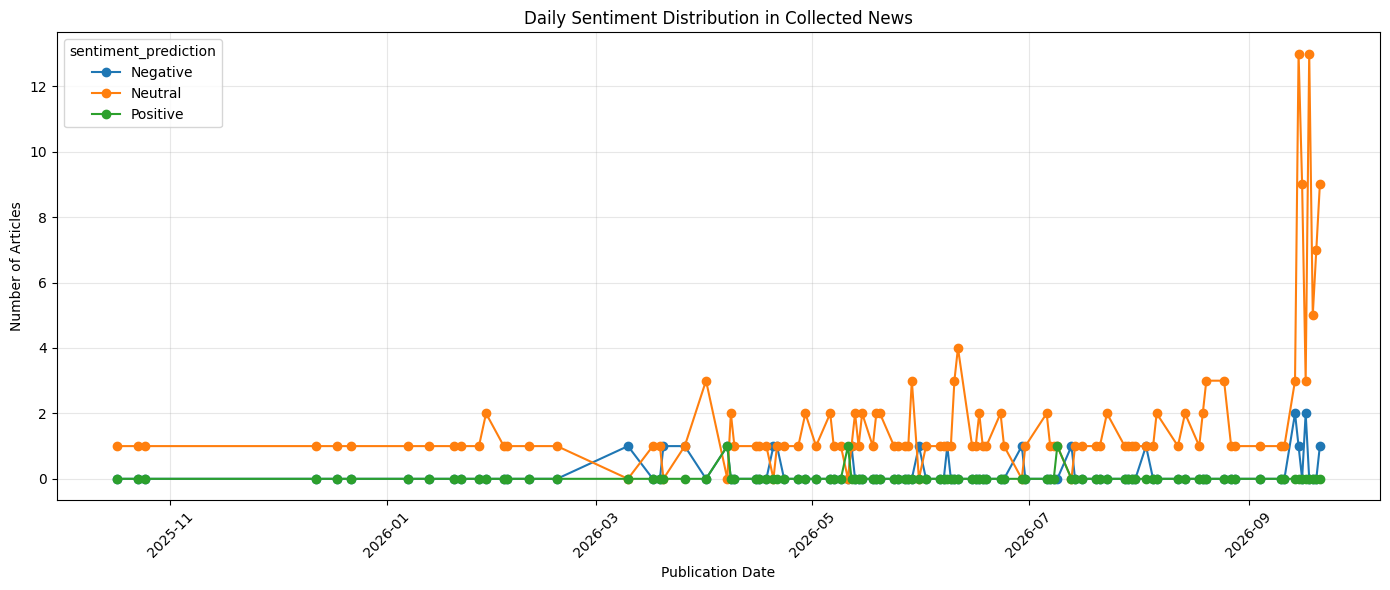

Saved: /content/round3_daily_sentiment.csv


In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare publication date and sentiment columns
df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)

df["publication_date"] = df["published_at"].dt.date

# Exclude invalid / placeholder dates from this chart
plot_df = df[
    df["published_at"].notna() &
    (df["published_at"] >= "2000-01-01")
].copy()

# Count each sentiment by publication date
daily_sentiment = (
    plot_df.groupby(["publication_date", "sentiment_prediction"])
    .size()
    .unstack(fill_value=0)
)

# Plot daily sentiment counts
daily_sentiment.plot(
    kind="line",
    marker="o",
    figsize=(14, 6)
)

plt.title("Daily Sentiment Distribution in Collected News")
plt.xlabel("Publication Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save chart data
daily_sentiment.to_csv(
    "/content/round3_daily_sentiment.csv"
)

print("Saved: /content/round3_daily_sentiment.csv")

In [91]:
# Show example articles for each predicted topic

for topic in df["topic_prediction"].dropna().unique():
    print("\nTOPIC:", topic)

    examples = df.loc[
        df["topic_prediction"] == topic,
        ["title", "source", "published_at"]
    ].head(3)

    display(examples)

# Save examples for the report
topic_examples = (
    df.groupby("topic_prediction", group_keys=False)
      .head(3)[["topic_prediction", "title", "source", "published_at"]]
)

topic_examples.to_csv(
    "/content/round3_topic_examples.csv",
    index=False
)

print("Saved: /content/round3_topic_examples.csv")


TOPIC: Community_Discussion


,title,source,published_at
0,Cybercrime feud erupts on dark web as notoriou...,Reuters,2026-09-21 01:58:00+00:00
1,Be careful before finding Garba partners onlin...,Bhaskar English,2026-09-21 01:57:09+00:00
2,Mumbai Cybercrime police arrest two from Bihar...,The Hindu,2026-08-20 07:00:00+00:00



TOPIC: Account_Security


,title,source,published_at
42,Raipur Cybercrime: Kids Gaming Leads To Bank A...,Bhaskar English,2026-09-19 02:52:11+00:00



TOPIC: Technical_Issues


,title,source,published_at
45,Global cybercrime crackdown: over 373 000 dark...,Europol,2026-03-20 07:00:00+00:00
121,The true measure of digital inclusion is how e...,Down To Earth,2026-06-29 07:00:00+00:00



TOPIC: Feature_Feedback


,title,source,published_at
60,Winner Announcement for Cyber Smart Idea Chall...,MyGov Blogs,2026-01-07 08:00:00+00:00


Saved: /content/round3_topic_examples.csv


In [92]:
import pandas as pd

# Convert publication timestamps
df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)

# Keep valid publication dates for activity analysis
activity_df = df[
    df["published_at"].notna() &
    (df["published_at"] >= "2000-01-01")
].copy()

activity_df["publication_date"] = (
    activity_df["published_at"].dt.date
)

# Count articles per publication date
daily_activity = (
    activity_df.groupby("publication_date")
    .size()
    .reset_index(name="article_count")
    .sort_values("publication_date")
)

display(daily_activity)

# Show busiest publication date
busiest = daily_activity.loc[
    daily_activity["article_count"].idxmax()
]

print("Busiest date:", busiest["publication_date"])
print("Articles that date:", busiest["article_count"])

# Save results
daily_activity.to_csv(
    "/content/round3_daily_activity.csv",
    index=False
)

print("Saved: /content/round3_daily_activity.csv")

,publication_date,article_count
0,2025-10-17,1
1,2025-10-23,1
2,2025-10-25,1
3,2025-12-12,1
4,2025-12-18,1
...,...,...
98,2026-09-17,5
99,2026-09-18,13
100,2026-09-19,5
101,2026-09-20,7


Busiest date: 2026-09-15
Articles that date: 14
Saved: /content/round3_daily_activity.csv


In [93]:
import pandas as pd

df = pd.read_csv("/content/round3_analyzed_news.csv")

# Convert publication and collection times
df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)
df["collected_at"] = pd.to_datetime(
    df["collected_at"], errors="coerce", utc=True
)

# Count articles by publication date
df["publication_date"] = df["published_at"].dt.date

daily_activity = (
    df.dropna(subset=["publication_date"])
      .groupby("publication_date")
      .size()
      .reset_index(name="article_count")
      .sort_values("publication_date")
)

print("Daily article activity:")
display(daily_activity)

# Check collection time span
print("\nCollection start:", df["collected_at"].min())
print("Collection end:", df["collected_at"].max())

# Save activity summary
daily_activity.to_csv(
    "/content/round3_daily_activity.csv",
    index=False
)

print("\nSaved: round3_daily_activity.csv")

Daily article activity:


,publication_date,article_count
0,1970-01-01,2
1,2025-10-17,1
2,2025-10-23,1
3,2025-10-25,1
4,2025-12-12,1
...,...,...
99,2026-09-17,5
100,2026-09-18,13
101,2026-09-19,5
102,2026-09-20,7



Collection start: 2026-09-21 07:48:20.435845+00:00
Collection end: 2026-09-21 07:48:21.109990+00:00

Saved: round3_daily_activity.csv


In [94]:
import pandas as pd

# Load the already analyzed dataset
df = pd.read_csv("/content/round3_analyzed_news.csv")

# Convert publication time to datetime
df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)

# Remove rows where publication time is missing
valid_df = df.dropna(subset=["published_at"]).copy()

# Get the publication date
valid_df["publication_date"] = (
    valid_df["published_at"].dt.date
)

# Count articles published each day
daily_activity = (
    valid_df.groupby("publication_date")
    .size()
    .reset_index(name="article_count")
    .sort_values("publication_date")
)

# Display and save the result
display(daily_activity)

daily_activity.to_csv(
    "/content/round3_daily_activity.csv",
    index=False
)

print("Saved: /content/round3_daily_activity.csv")

,publication_date,article_count
0,1970-01-01,2
1,2025-10-17,1
2,2025-10-23,1
3,2025-10-25,1
4,2025-12-12,1
...,...,...
99,2026-09-17,5
100,2026-09-18,13
101,2026-09-19,5
102,2026-09-20,7


Saved: /content/round3_daily_activity.csv


In [95]:
import feedparser
import pandas as pd
from datetime import datetime, timezone
from urllib.parse import quote
from pathlib import Path

# Record the time of this collection
snapshot_time = datetime.now(timezone.utc).isoformat()

# Use the same topics as the original collection
topics = {
    "cybercrime": '"cybercrime" OR "online fraud" OR "digital scam"',
    "digital_exclusion": '"digital exclusion" OR "digital divide" OR "internet access"'
}

rows = []

# Collect fresh articles from Google News RSS
for category, query in topics.items():
    url = (
        "https://news.google.com/rss/search?q="
        + quote(query)
        + "&hl=en-IN&gl=IN&ceid=IN:en"
    )

    feed = feedparser.parse(url)

    for entry in feed.entries:
        rows.append({
            "title": entry.get("title", ""),
            "summary": entry.get("summary", ""),
            "url": entry.get("link", ""),
            "published_at": entry.get("published", ""),
            "collected_at": snapshot_time,
            "snapshot_time": snapshot_time,
            "source": entry.get("source", {}).get("title", ""),
            "search_category": category
        })

# Create a DataFrame from the new collection
new_df = pd.DataFrame(rows)

# Clean the new data
if not new_df.empty:
    new_df = new_df.drop_duplicates(subset=["url"])
    new_df["title"] = new_df["title"].fillna("").astype(str).str.strip()
    new_df["summary"] = new_df["summary"].fillna("").astype(str)
    new_df = new_df[new_df["title"] != ""].copy()

    # Prepare text for the Round 2 models
    new_df["analysis_text"] = (
        new_df["title"] + " " + new_df["summary"]
    ).str.strip()

    # Apply the already loaded Round 2 models
    new_df["sentiment_prediction"] = sentiment_model.predict(
        new_df["analysis_text"]
    )
    new_df["topic_prediction"] = topic_model.predict(
        new_df["analysis_text"]
    )

    # Save this snapshot separately
    output_path = Path("/content/round3_new_snapshot.csv")
    new_df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print("New articles collected:", len(new_df))
    print("Snapshot time (UTC):", snapshot_time)
    print("Saved to:", output_path)

else:
    print("No articles returned by the RSS feeds.")

New articles collected: 200
Snapshot time (UTC): 2026-09-21T07:48:37.510954+00:00
Saved to: /content/round3_new_snapshot.csv


In [108]:

import pandas as pd

df1 = pd.read_csv(
    "/content/DATA_VORTEX_R3_news_dataset_1.csv"
)
df2 = pd.read_csv(
    "/content/DATA_VORTEX_R3_news_dataset_2.csv"
)

print("===== DATASET 1: COLUMN NAMES =====")
print(df1.columns.tolist())
display(df1.head(3))

print("\n===== DATASET 2: COLUMN NAMES =====")
print(df2.columns.tolist())
display(df2.head(3))

===== DATASET 1: COLUMN NAMES =====
['title', 'summary', 'url', 'published_at', 'collected_at', 'source', 'search_category']


,title,summary,url,published_at,collected_at,source,search_category
0,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiwgFBV...,"Mon, 21 Sep 2026 01:57:09 GMT",2026-09-21T02:59:38.359876+00:00,Bhaskar English,cybercrime
1,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiyAFBV...,"Mon, 21 Sep 2026 01:58:00 GMT",2026-09-21T02:59:38.359907+00:00,Reuters,cybercrime
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi5AFBV...,"Thu, 20 Aug 2026 07:00:00 GMT",2026-09-21T02:59:38.359918+00:00,The Hindu,cybercrime



===== DATASET 2: COLUMN NAMES =====
['title', 'summary', 'url', 'published_at', 'collected_at', 'source', 'search_category']


,title,summary,url,published_at,collected_at,source,search_category
0,Cybercrime feud erupts on dark web as notoriou...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiyAFBV...,"Mon, 21 Sep 2026 01:58:00 GMT",2026-09-21T07:48:20.435845+00:00,Reuters,cybercrime
1,Be careful before finding Garba partners onlin...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiwgFBV...,"Mon, 21 Sep 2026 01:57:09 GMT",2026-09-21T07:48:20.435890+00:00,Bhaskar English,cybercrime
2,Mumbai Cybercrime police arrest two from Bihar...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi5AFBV...,"Thu, 20 Aug 2026 07:00:00 GMT",2026-09-21T07:48:20.435908+00:00,The Hindu,cybercrime


In [109]:

# Runtime mein loaded model/pipeline variables dhoondo
from sklearn.pipeline import Pipeline

for name, obj in globals().copy().items():
    if isinstance(obj, Pipeline):
        print(name, "->", type(obj).__name__)

sentiment_model -> Pipeline
topic_model -> Pipeline


In [110]:
import pandas as pd
from pathlib import Path

# Exact filenames you gave
file1 = "/content/DATA_VORTEX_R3_news_dataset_1.csv"
file2 = "/content/DATA_VORTEX_R3_news_dataset_2.csv"

def analyze_csv(file_path):
    df = pd.read_csv(file_path)

    # Prepare text for the Round 2 models
    df["analysis_text"] = (
        df["title"].fillna("").astype(str) + " " +
        df["summary"].fillna("").astype(str)
    ).str.strip()

    # Apply the loaded pipelines
    df["sentiment_prediction"] = sentiment_model.predict(
        df["analysis_text"]
    )
    df["topic_prediction"] = topic_model.predict(
        df["analysis_text"]
    )

    # Save analyzed copy; raw CSV remains unchanged
    output_path = file_path.replace(".csv", "_analyzed.csv")
    df.to_csv(output_path, index=False)

    print(f"\nAnalyzed: {Path(file_path).name}")
    print("Rows:", len(df))
    print("\nSentiment counts:")
    print(df["sentiment_prediction"].value_counts(dropna=False))
    print("\nTopic counts:")
    print(df["topic_prediction"].value_counts(dropna=False))
    print("\nSaved:", output_path)

    return df

df1 = analyze_csv(file1)
df2 = analyze_csv(file2)


Analyzed: DATA_VORTEX_R3_news_dataset_1.csv
Rows: 200

Sentiment counts:
sentiment_prediction
Neutral     179
Negative     18
Positive      3
Name: count, dtype: int64

Topic counts:
topic_prediction
Community_Discussion    196
Technical_Issues          2
Account_Security          1
Feature_Feedback          1
Name: count, dtype: int64

Saved: /content/DATA_VORTEX_R3_news_dataset_1_analyzed.csv

Analyzed: DATA_VORTEX_R3_news_dataset_2.csv
Rows: 200

Sentiment counts:
sentiment_prediction
Neutral     179
Negative     18
Positive      3
Name: count, dtype: int64

Topic counts:
topic_prediction
Community_Discussion    196
Technical_Issues          2
Account_Security          1
Feature_Feedback          1
Name: count, dtype: int64

Saved: /content/DATA_VORTEX_R3_news_dataset_2_analyzed.csv


In [111]:
print("DATASET 1 vs DATASET 2")
print("=" * 40)

print("\n1. Article counts")
print("Dataset 1:", len(df1))
print("Dataset 2:", len(df2))

print("\n2. Sentiment comparison")
sentiment_comparison = pd.concat(
    [
        df1["sentiment_prediction"].value_counts().rename("Dataset 1"),
        df2["sentiment_prediction"].value_counts().rename("Dataset 2")
    ],
    axis=1
).fillna(0).astype(int)

display(sentiment_comparison)

print("\n3. Topic comparison")
topic_comparison = pd.concat(
    [
        df1["topic_prediction"].value_counts().rename("Dataset 1"),
        df2["topic_prediction"].value_counts().rename("Dataset 2")
    ],
    axis=1
).fillna(0).astype(int)

display(topic_comparison)

print("\n4. URL overlap")
urls1 = set(df1["url"].dropna().astype(str))
urls2 = set(df2["url"].dropna().astype(str))

common_urls = urls1.intersection(urls2)
print("Common URLs:", len(common_urls))
print("Unique to Dataset 1:", len(urls1 - urls2))
print("Unique to Dataset 2:", len(urls2 - urls1))

DATASET 1 vs DATASET 2

1. Article counts
Dataset 1: 200
Dataset 2: 200

2. Sentiment comparison


,Dataset 1,Dataset 2
sentiment_prediction,,
Neutral,179,179
Negative,18,18
Positive,3,3



3. Topic comparison


,Dataset 1,Dataset 2
topic_prediction,,
Community_Discussion,196,196
Technical_Issues,2,2
Account_Security,1,1
Feature_Feedback,1,1



4. URL overlap
Common URLs: 166
Unique to Dataset 1: 34
Unique to Dataset 2: 34


In [112]:
import os
print(os.listdir("/content"))

['.config', 'DATA VORTEX ROUND 2.zip', 'round3_topic_examples.csv', 'news_snapshot_20260921_072505.csv', 'news_snapshot_20260921_074821.csv', 'round2_files', 'round3_source_summary.csv', 'DATA_VORTEX_R3_news_dataset_2.csv', 'DATA_VORTEX_R3_news_dataset_clean.csv', 'round3_daily_sentiment.csv', 'round3_daily_activity.csv', 'round3_topic_summary.csv', 'round3_new_snapshot.csv', 'round3_final_sentiment_counts.csv', 'manual_review_sample.csv', 'round3_duplicates_check.csv', 'round3_collection_batches.csv', 'round3_weekly_sentiment.csv', 'DATA_VORTEX_R3_news_dataset_1_analyzed.csv', 'round3_sentiment_summary.csv', 'round3_analyzed_news.csv', 'news_snapshot_20260921_072744.csv', 'DATA_VORTEX_R3_news_dataset_1.csv', 'DATA_VORTEX_R3_news_dataset_2_analyzed.csv', 'news_snapshot_20260921_072446.csv', 'news_snapshot_20260921_072746.csv', 'round3_suspicious_dates.csv', 'news_snapshot_20260921_072456.csv', 'DATA_VORTEX_R3_news_dataset.csv', 'round3_keyword_summary.csv', 'round3_final_topic_counts.c

In [113]:
# Compare sentiment percentages
sentiment_pct = pd.concat([
    df1["sentiment_prediction"].value_counts(normalize=True).mul(100).rename("Dataset 1 (%)"),
    df2["sentiment_prediction"].value_counts(normalize=True).mul(100).rename("Dataset 2 (%)")
], axis=1).fillna(0).round(2)

display(sentiment_pct)

# Compare topic percentages
topic_pct = pd.concat([
    df1["topic_prediction"].value_counts(normalize=True).mul(100).rename("Dataset 1 (%)"),
    df2["topic_prediction"].value_counts(normalize=True).mul(100).rename("Dataset 2 (%)")
], axis=1).fillna(0).round(2)

display(topic_pct)

# Duplicate/overlap check
urls1 = set(df1["url"].dropna().astype(str))
urls2 = set(df2["url"].dropna().astype(str))

print("Shared URLs:", len(urls1 & urls2))
print("Dataset 1 unique URLs:", len(urls1 - urls2))
print("Dataset 2 unique URLs:", len(urls2 - urls1))

,Dataset 1 (%),Dataset 2 (%)
sentiment_prediction,,
Neutral,89.5,89.5
Negative,9.0,9.0
Positive,1.5,1.5


,Dataset 1 (%),Dataset 2 (%)
topic_prediction,,
Community_Discussion,98.0,98.0
Technical_Issues,1.0,1.0
Account_Security,0.5,0.5
Feature_Feedback,0.5,0.5


Shared URLs: 166
Dataset 1 unique URLs: 34
Dataset 2 unique URLs: 34


In [114]:
# Parse timestamps
for df in [df1, df2]:
    df["published_at"] = pd.to_datetime(
        df["published_at"], errors="coerce", utc=True
    )
    df["collected_at"] = pd.to_datetime(
        df["collected_at"], errors="coerce", utc=True
    )

def show_time_summary(df, name):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Published range:",
          df["published_at"].min(), "to", df["published_at"].max())
    print("Collected range:",
          df["collected_at"].min(), "to", df["collected_at"].max())
    print("Distinct collection timestamps:",
          df["collected_at"].nunique())
    print("Missing published_at:", df["published_at"].isna().sum())
    print("Missing collected_at:", df["collected_at"].isna().sum())

show_time_summary(df1, "DATASET 1")
show_time_summary(df2, "DATASET 2")


DATASET 1
Rows: 200
Published range: 1970-01-01 00:00:00+00:00 to 2026-09-21 01:58:00+00:00
Collected range: 2026-09-21 02:59:38.359876+00:00 to 2026-09-21 02:59:39.140428+00:00
Distinct collection timestamps: 200
Missing published_at: 0
Missing collected_at: 0

DATASET 2
Rows: 200
Published range: 1970-01-01 00:00:00+00:00 to 2026-09-21 07:45:38+00:00
Collected range: 2026-09-21 07:48:20.435845+00:00 to 2026-09-21 07:48:21.109990+00:00
Distinct collection timestamps: 200
Missing published_at: 0
Missing collected_at: 0


In [115]:
shared = df1[["url", "collected_at"]].merge(
    df2[["url", "collected_at"]],
    on="url",
    how="inner",
    suffixes=("_1", "_2")
)

shared["collection_gap_hours"] = (
    shared["collected_at_2"] - shared["collected_at_1"]
).dt.total_seconds() / 3600

print("Shared articles:", len(shared))
print("Different collection timestamps:",
      (shared["collection_gap_hours"] != 0).sum())
print("Median collection gap (hours):",
      shared["collection_gap_hours"].median())

display(shared.head(10))

Shared articles: 166
Different collection timestamps: 166
Median collection gap (hours): 4.811687791388889


,url,collected_at_1,collected_at_2,collection_gap_hours
0,https://news.google.com/rss/articles/CBMiwgFBV...,2026-09-21 02:59:38.359876+00:00,2026-09-21 07:48:20.435890+00:00,4.811688
1,https://news.google.com/rss/articles/CBMiyAFBV...,2026-09-21 02:59:38.359907+00:00,2026-09-21 07:48:20.435845+00:00,4.811688
2,https://news.google.com/rss/articles/CBMi5AFBV...,2026-09-21 02:59:38.359918+00:00,2026-09-21 07:48:20.435908+00:00,4.811688
3,https://news.google.com/rss/articles/CBMioAFBV...,2026-09-21 02:59:38.359926+00:00,2026-09-21 07:48:20.435923+00:00,4.811688
4,https://news.google.com/rss/articles/CBMisAFBV...,2026-09-21 02:59:38.359935+00:00,2026-09-21 07:48:20.435953+00:00,4.811688
5,https://news.google.com/rss/articles/CBMiqwFBV...,2026-09-21 02:59:38.359943+00:00,2026-09-21 07:48:20.435967+00:00,4.811688
6,https://news.google.com/rss/articles/CBMi7AFBV...,2026-09-21 02:59:38.359952+00:00,2026-09-21 07:48:20.435996+00:00,4.811688
7,https://news.google.com/rss/articles/CBMiiwFBV...,2026-09-21 02:59:38.359959+00:00,2026-09-21 07:48:20.435981+00:00,4.811688
8,https://news.google.com/rss/articles/CBMi0wFBV...,2026-09-21 02:59:38.359968+00:00,2026-09-21 07:48:20.436053+00:00,4.811688
9,https://news.google.com/rss/articles/CBMixAFBV...,2026-09-21 02:59:38.359978+00:00,2026-09-21 07:48:20.436024+00:00,4.811688


In [116]:
shared = df1[["url", "collected_at"]].merge(
    df2[["url", "collected_at"]],
    on="url",
    how="inner",
    suffixes=("_1", "_2")
)

shared["gap_hours"] = (
    shared["collected_at_2"] - shared["collected_at_1"]
).dt.total_seconds() / 3600

print("Shared URLs:", len(shared))
print("Same collection time:",
      (shared["gap_hours"] == 0).sum())
print("Different collection time:",
      (shared["gap_hours"] != 0).sum())
print("Median gap (hours):", shared["gap_hours"].median())
print("Min gap (hours):", shared["gap_hours"].min())
print("Max gap (hours):", shared["gap_hours"].max())

display(shared.head(10))

Shared URLs: 166
Same collection time: 0
Different collection time: 166
Median gap (hours): 4.811687791388889
Min gap (hours): 4.8116579391666665
Max gap (hours): 4.811688026944444


,url,collected_at_1,collected_at_2,gap_hours
0,https://news.google.com/rss/articles/CBMiwgFBV...,2026-09-21 02:59:38.359876+00:00,2026-09-21 07:48:20.435890+00:00,4.811688
1,https://news.google.com/rss/articles/CBMiyAFBV...,2026-09-21 02:59:38.359907+00:00,2026-09-21 07:48:20.435845+00:00,4.811688
2,https://news.google.com/rss/articles/CBMi5AFBV...,2026-09-21 02:59:38.359918+00:00,2026-09-21 07:48:20.435908+00:00,4.811688
3,https://news.google.com/rss/articles/CBMioAFBV...,2026-09-21 02:59:38.359926+00:00,2026-09-21 07:48:20.435923+00:00,4.811688
4,https://news.google.com/rss/articles/CBMisAFBV...,2026-09-21 02:59:38.359935+00:00,2026-09-21 07:48:20.435953+00:00,4.811688
5,https://news.google.com/rss/articles/CBMiqwFBV...,2026-09-21 02:59:38.359943+00:00,2026-09-21 07:48:20.435967+00:00,4.811688
6,https://news.google.com/rss/articles/CBMi7AFBV...,2026-09-21 02:59:38.359952+00:00,2026-09-21 07:48:20.435996+00:00,4.811688
7,https://news.google.com/rss/articles/CBMiiwFBV...,2026-09-21 02:59:38.359959+00:00,2026-09-21 07:48:20.435981+00:00,4.811688
8,https://news.google.com/rss/articles/CBMi0wFBV...,2026-09-21 02:59:38.359968+00:00,2026-09-21 07:48:20.436053+00:00,4.811688
9,https://news.google.com/rss/articles/CBMixAFBV...,2026-09-21 02:59:38.359978+00:00,2026-09-21 07:48:20.436024+00:00,4.811688


In [117]:
import pandas as pd

# Preserve which batch each article came from
a = df1.copy()
b = df2.copy()

a["batch"] = "Dataset 1"
b["batch"] = "Dataset 2"

combined = pd.concat([a, b], ignore_index=True)

# Flag suspicious Unix-epoch publication dates
combined["published_at"] = pd.to_datetime(
    combined["published_at"], errors="coerce", utc=True
)

combined["date_quality"] = "OK"
combined.loc[
    combined["published_at"].isna(),
    "date_quality"
] = "Missing/Invalid"

combined.loc[
    combined["published_at"].dt.year.eq(1970),
    "date_quality"
] = "Suspicious 1970 date"

# Count batch appearances for each URL
batch_info = (
    combined.groupby("url")["batch"]
    .agg(lambda x: ", ".join(sorted(set(x))))
    .rename("appeared_in")
)

# Keep the latest collected copy for each URL
combined = combined.sort_values("collected_at")
clean_df = combined.drop_duplicates(subset="url", keep="last").copy()

clean_df = clean_df.merge(
    batch_info,
    left_on="url",
    right_index=True,
    how="left"
)

# Save cleaned dataset
output_file = "/content/DATA_VORTEX_R3_combined_clean.csv"
clean_df.to_csv(output_file, index=False)

print("Original total rows:", len(df1) + len(df2))
print("Unique URLs after deduplication:", clean_df["url"].nunique())
print("Rows in clean dataset:", len(clean_df))
print("\nBatch overlap:")
print(clean_df["appeared_in"].value_counts())

print("\nPublication date quality:")
print(clean_df["date_quality"].value_counts())

print("\nSaved:", output_file)

Original total rows: 400
Unique URLs after deduplication: 234
Rows in clean dataset: 234

Batch overlap:
appeared_in
Dataset 1, Dataset 2    166
Dataset 1                34
Dataset 2                34
Name: count, dtype: int64

Publication date quality:
date_quality
OK                      232
Suspicious 1970 date      2
Name: count, dtype: int64

Saved: /content/DATA_VORTEX_R3_combined_clean.csv


In [118]:
import pandas as pd

df = pd.read_csv("/content/DATA_VORTEX_R3_combined_clean.csv")

# Sentiment distribution
print("SENTIMENT COUNTS")
display(df["sentiment_prediction"].value_counts().to_frame("Articles"))

print("\nSENTIMENT PERCENTAGES")
display(
    df["sentiment_prediction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percent")
)

# Topic distribution
print("\nTOPIC COUNTS")
display(df["topic_prediction"].value_counts().to_frame("Articles"))

# Top news sources
print("\nTOP 10 SOURCES")
display(df["source"].value_counts().head(10).to_frame("Articles"))

# Batch distribution by sentiment
print("\nSENTIMENT BY BATCH")
display(pd.crosstab(df["appeared_in"], df["sentiment_prediction"]))

# Publication date quality
print("\nDATE QUALITY")
display(df["date_quality"].value_counts().to_frame("Rows"))

SENTIMENT COUNTS


,Articles
sentiment_prediction,
Neutral,211
Negative,20
Positive,3



SENTIMENT PERCENTAGES


,Percent
sentiment_prediction,
Neutral,90.17
Negative,8.55
Positive,1.28



TOPIC COUNTS


...

,Articles
source,
coe.int,11
Nature,8
Interpol,5
Bhaskar English,4
United Nations Office on Drugs and Crime,4
Frontiers,4
The Hindu,4
Deccan Herald,3
The World Economic Forum,3



SENTIMENT BY BATCH


sentiment_prediction,Negative,Neutral,Positive
appeared_in,,,
Dataset 1,2,32,0
"Dataset 1, Dataset 2",16,147,3
Dataset 2,2,32,0



DATE QUALITY


,Rows
date_quality,
OK,232
Suspicious 1970 date,2


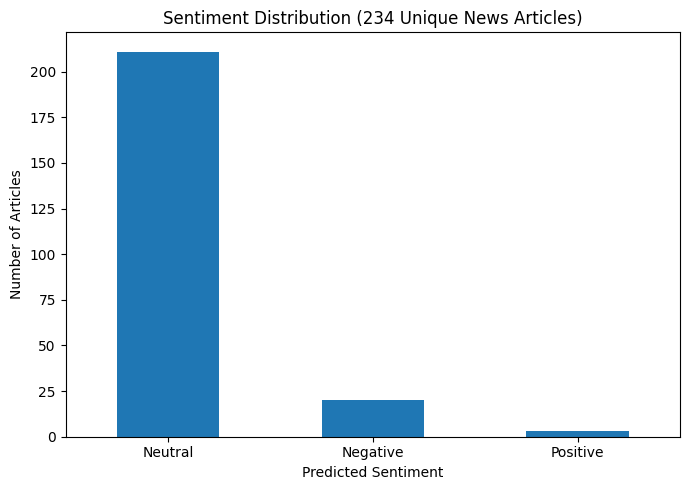

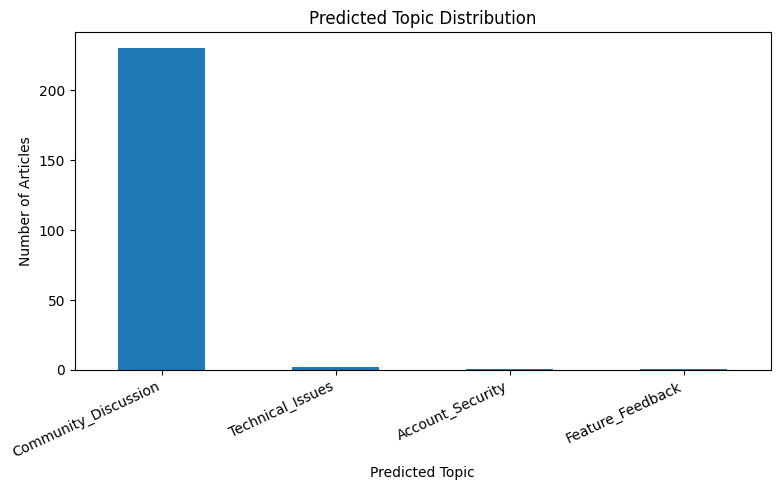

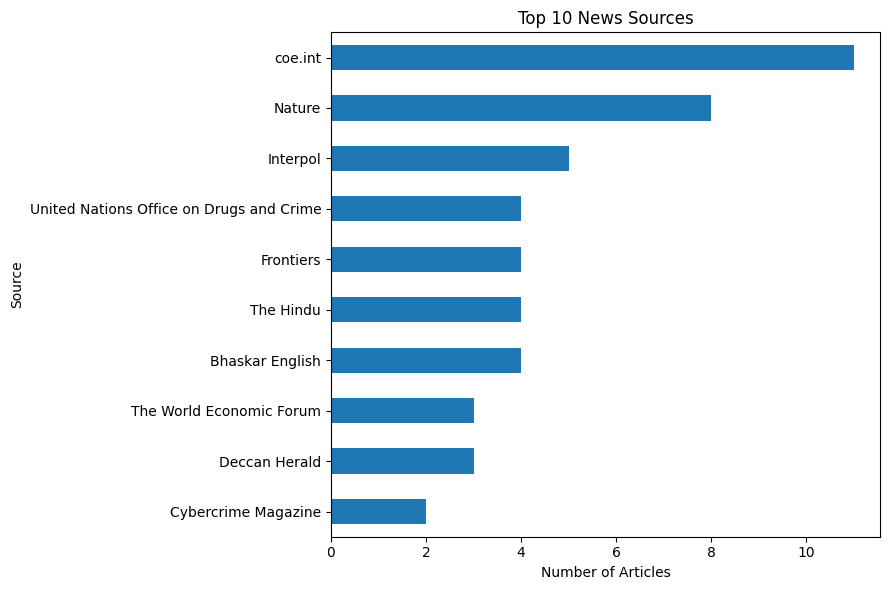

Saved 3 charts in /content/


In [119]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DATA_VORTEX_R3_combined_clean.csv")

# 1. Sentiment distribution
sentiment_counts = df["sentiment_prediction"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution (234 Unique News Articles)")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/R3_sentiment_distribution.png", dpi=200)
plt.show()

# 2. Topic distribution
topic_counts = df["topic_prediction"].value_counts()

plt.figure(figsize=(8, 5))
topic_counts.plot(kind="bar")
plt.title("Predicted Topic Distribution")
plt.xlabel("Predicted Topic")
plt.ylabel("Number of Articles")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("/content/R3_topic_distribution.png", dpi=200)
plt.show()

# 3. Top 10 sources
source_counts = df["source"].value_counts().head(10).sort_values()

plt.figure(figsize=(9, 6))
source_counts.plot(kind="barh")
plt.title("Top 10 News Sources")
plt.xlabel("Number of Articles")
plt.ylabel("Source")
plt.tight_layout()
plt.savefig("/content/R3_top_sources.png", dpi=200)
plt.show()

print("Saved 3 charts in /content/")

Valid articles for publication-time analysis: 232
Excluded suspicious/invalid dates: 2

Top 10 publication hours:


,Article count
published_hour,
2026-09-15 07:00:00+00:00,4
2026-03-26 07:00:00+00:00,3
2026-06-10 07:00:00+00:00,3
2026-04-01 07:00:00+00:00,3
2026-06-11 07:00:00+00:00,3
2026-08-25 07:00:00+00:00,3
2026-09-21 01:00:00+00:00,3
2026-09-19 02:00:00+00:00,3
2026-08-20 07:00:00+00:00,3


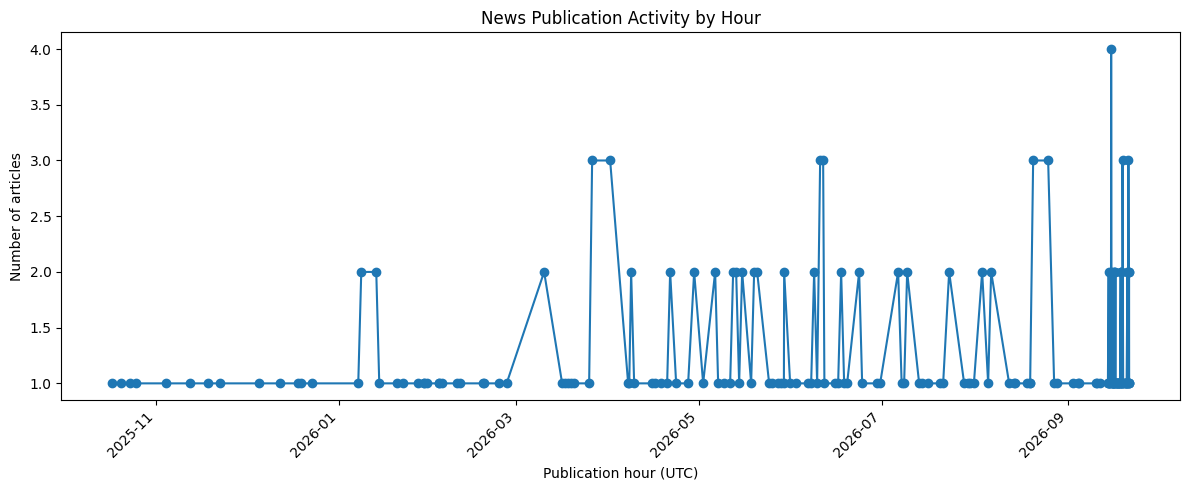

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DATA_VORTEX_R3_combined_clean.csv")

df["published_at"] = pd.to_datetime(
    df["published_at"], errors="coerce", utc=True
)

# Exclude invalid/epoch publication dates from time-based analysis
valid = df[
    df["published_at"].notna() &
    (df["published_at"].dt.year > 1970)
].copy()

valid["published_hour"] = valid["published_at"].dt.floor("h")

hourly = (
    valid.groupby("published_hour")
    .size()
    .sort_index()
)

print("Valid articles for publication-time analysis:", len(valid))
print("Excluded suspicious/invalid dates:", len(df) - len(valid))
print("\nTop 10 publication hours:")
display(hourly.sort_values(ascending=False).head(10).to_frame("Article count"))

plt.figure(figsize=(12, 5))
hourly.plot(kind="line", marker="o")
plt.title("News Publication Activity by Hour")
plt.xlabel("Publication hour (UTC)")
plt.ylabel("Number of articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/R3_hourly_publication_activity.png", dpi=200)
plt.show()

In [121]:
import os
import pandas as pd

files = [
    "/content/DATA_VORTEX_R3_combined_clean.csv",
    "/content/R3_sentiment_distribution.png",
    "/content/R3_topic_distribution.png",
    "/content/R3_top_sources.png",
    "/content/R3_hourly_publication_activity.png"
]

print("FINAL FILE CHECK")
for f in files:
    print(("✅ " if os.path.exists(f) else "❌ "), os.path.basename(f))

df = pd.read_csv(files[0])

print("\nDataset rows:", len(df))
print("Sentiment labels:", df["sentiment_prediction"].value_counts().to_dict())
print("Topic labels:", df["topic_prediction"].value_counts().to_dict())

FINAL FILE CHECK
✅  DATA_VORTEX_R3_combined_clean.csv
✅  R3_sentiment_distribution.png
✅  R3_topic_distribution.png
✅  R3_top_sources.png
✅  R3_hourly_publication_activity.png

Dataset rows: 234
Sentiment labels: {'Neutral': 211, 'Negative': 20, 'Positive': 3}
Topic labels: {'Community_Discussion': 230, 'Technical_Issues': 2, 'Account_Security': 1, 'Feature_Feedback': 1}


In [122]:
!pip -q install reportlab

from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

pdf_path = "/content/DATA_VORTEX_R3_Final_Report.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=45, leftMargin=45,
    topMargin=45, bottomMargin=45
)

styles = getSampleStyleSheet()
story = []

story.append(Paragraph(
    "DATA VORTEX A'26 — Round 3",
    styles["Title"]
))
story.append(Paragraph(
    "Public Reaction to a Trending Social Issue",
    styles["Heading2"]
))
story.append(Paragraph(
    "Focus: Cybercrime and Digital Exclusion",
    styles["Normal"]
))
story.append(Spacer(1, 16))

sections = [
    ("1. Data Collection Method",
     "News articles were collected using Google News RSS in two batches. "
     "The dataset includes article titles, summaries, URLs, publication "
     "timestamps, collection timestamps, sources, and search categories. "
     "Round 2 sentiment and topic pipelines were applied to article text."),

    ("2. Time Window",
     "Dataset 1 was collected around 2026-09-21 02:59:38 UTC. "
     "Dataset 2 was collected around 2026-09-21 07:48:20 UTC. "
     "The median collection-time gap among 166 shared URLs was "
     "approximately 4.812 hours. The batches are overlapping collections, "
     "not independent social-media snapshots."),

    ("3. Sentiment Analysis",
     "After URL deduplication, 234 unique articles remained. "
     "Predicted sentiment: Neutral 211 (90.17%), Negative 20 (8.55%), "
     "Positive 3 (1.28%). These are model predictions on news text, "
     "not direct measurements of public sentiment."),

    ("4. Activity Analysis",
     "The dataset contains 400 raw rows across two batches and 234 unique "
     "URLs after deduplication. Article collection volume is not equivalent "
     "to likes, comments, shares, or social engagement. No verified "
     "engagement spike can be established from these fields."),

    ("5. Topic and Entity Analysis",
     "Predicted topics: Community_Discussion 230 (98.29%), "
     "Technical_Issues 2, Account_Security 1, and Feature_Feedback 1. "
     "The high concentration in one predicted class should be interpreted "
     "cautiously and may reflect model-label limitations."),

    ("6. Trigger Explanations",
     "The available data does not establish two sentiment shifts or causal "
     "triggers. News themes may provide context, but without social "
     "interaction data and multiple validated time-series observations, "
     "they cannot be treated as confirmed causes."),

    ("7. Data Quality and Limitations",
     "Two records contain suspicious publication timestamps at "
     "1970-01-01 and were flagged. The dataset is news-based, has substantial "
     "URL overlap between batches, and uses model-generated labels. "
     "Results should not be generalized as direct measures of social-media "
     "public reaction.")
]

for heading, text in sections:
    story.append(Paragraph(heading, styles["Heading2"]))
    story.append(Paragraph(text, styles["BodyText"]))
    story.append(Spacer(1, 10))

story.append(Paragraph(
    "Dataset summary",
    styles["Heading2"]
))

table_data = [
    ["Metric", "Result"],
    ["Raw rows", "400"],
    ["Unique URLs after deduplication", "234"],
    ["URLs in both batches", "166"],
    ["Dataset 1 only", "34"],
    ["Dataset 2 only", "34"],
    ["Suspicious 1970 dates", "2"],
]

table = Table(table_data, colWidths=[3.4*inch, 2.2*inch])
table.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("PADDING", (0,0), (-1,-1), 6),
]))
story.append(table)

doc.build(story)

print("PDF saved:", pdf_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.1 MB/s eta 0:00:00
PDF saved: /content/DATA_VORTEX_R3_Final_Report.pdf
